# Mini GPT from Scratch

For this assignment I built a small GPT-style decoder-only transformer completely from scratch in PyTorch. I couldn't use `nn.Transformer`, `nn.MultiheadAttention`, or any HuggingFace stuff, so everything below (attention, the decoder blocks, the whole model) is written by hand using just `nn.Linear`, `nn.LayerNorm`, `nn.GELU` and basic tensor ops.

This builds on the single-head demo we went over in class (`Demo_4_Mini_GPT.ipynb`), but extends it to:

- multi-head attention (4 heads) instead of 1 head
- 4 decoder blocks stacked instead of 1
- a longer sequence length (128 instead of 64)
- proper training with a loss curve
- three different decoding methods (greedy, temperature, top-k) so I can compare them

I'm using `shakespeare.txt` as the training data, which is just the Romeo and Juliet balcony scene (it's pretty short). Because of that the model ends up mostly memorizing this passage instead of learning general English - I talk about this more at the end.


## Part 0 - Imports and setup

Just importing torch and the other libraries I need, picking a device, and setting a seed so I get the same results every time I rerun this.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)


Device: cpu


## Part 1 - Getting the data ready

### 1.1 Character-level tokenization

First I read in the text file and build the vocabulary out of every unique character that shows up. Then I make two dictionaries, `char_to_idx` and `idx_to_char`, so I can go back and forth between characters and numbers (the model only understands numbers).


In [2]:
with open("shakespeare.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Total characters in the file:", len(text))
print(text[:200])


Total characters in the file: 1738
ROMEO:
But, soft! what light through yonder window breaks?
It is the east, and Juliet is the sun.
Arise, fair sun, and kill the envious moon,
Who is already sick and pale with grief,
That thou her mai


In [3]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join(idx_to_char[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

print("Vocab size:", vocab_size)
print("All the characters in the vocab:", "".join(chars))


Vocab size: 49
All the characters in the vocab: 
 !,.:;?ABCDEHIJLMNORSTUWabcdefghiklmnoprstuvwyz’


### 1.2 Sliding window dataset

The assignment wants sequence length 128, so I take a window of 128 characters as the input and the same window shifted over by one character as the target. That's basically how the model learns to predict "what comes next" - at every position in the window it's trying to guess the very next character.

One thing worth flagging: this text file is pretty small (under 2000 characters), so with a window of 128 I only get around 1600 overlapping training examples. That's not a lot of data, so I wasn't expecting the model to generalize well, more just show that the pipeline works end to end.


In [4]:
seq_len = 128

class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len - 1

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.seq_len]
        y = self.data[idx + 1:idx + self.seq_len + 1]
        return x, y

dataset = CharDataset(data, seq_len)
print("Number of training windows:", len(dataset))

batch_size = 16
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


Number of training windows: 1609


In [5]:
# just printing a couple examples so I can see the input/target pairs actually make sense
for i in [0, 50]:
    x, y = dataset[i]
    print(f"--- example {i} ---")
    print("input :", repr(decode(x.tolist())))
    print("target:", repr(decode(y.tolist())))
    print()


--- example 0 ---
input : 'ROMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the '
target: 'OMEO:\nBut, soft! what light through yonder window breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the e'

--- example 50 ---
input : ' breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the envious moon,\nWho is already sick and pale with gr'
target: 'breaks?\nIt is the east, and Juliet is the sun.\nArise, fair sun, and kill the envious moon,\nWho is already sick and pale with gri'



## Part 2 - The model

### 2.1 Multi-head masked self-attention (written by hand)

This is the main part of the assignment. Instead of one attention head like in the demo, I split things into 4 heads, each working on a smaller slice of the embedding (`head_dim = d_model / n_heads`). The idea is that different heads can pick up on different kinds of patterns instead of everything being crammed into one attention pattern.

How I built it:
1. Project the input into Q, K, V using linear layers.
2. Reshape each one into `[batch, heads, time, head_dim]` so every head gets its own chunk.
3. Do scaled dot product attention per head - `Q @ K^T / sqrt(head_dim)`.
4. Mask out anything in the future using a causal mask (upper triangular), so a character can't "cheat" by looking ahead.
5. Softmax, then multiply by V to get the weighted output.
6. Stick the heads back together and pass through one more linear layer.

No `nn.MultiheadAttention` anywhere, it's all just `nn.Linear` and matrix multiplies.


In [6]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model needs to divide evenly by n_heads"
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        # split into heads: [B, T, C] -> [B, H, T, D]
        Q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)
        K = self.k_proj(x).view(B, T, H, D).transpose(1, 2)
        V = self.v_proj(x).view(B, T, H, D).transpose(1, 2)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(D)  # [B, H, T, T]

        # causal mask so position t can't see anything after t
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = attn @ V  # [B, H, T, D]
        out = out.transpose(1, 2).contiguous().view(B, T, C)  # merge heads back
        out = self.out_proj(out)
        return out


In [7]:
# quick sanity check to make sure shapes come out right before I plug this into the model
test_input = torch.randn(2, 10, 32)
test_mha = MultiHeadSelfAttention(d_model=32, n_heads=4)
test_out = test_mha(test_input)
print("input shape :", test_input.shape)
print("output shape:", test_out.shape)
assert test_out.shape == test_input.shape
print("looks good, shapes match")


input shape : torch.Size([2, 10, 32])
output shape: torch.Size([2, 10, 32])
looks good, shapes match


### 2.2 Decoder block

Each block does the same two-step pattern:

1. Multi-head attention, with a residual connection and a LayerNorm
2. A feedforward network (Linear -> GELU -> Linear), with another residual + LayerNorm

I went with pre-norm (LayerNorm before each sub-layer, not after) since that's generally easier to train when you stack multiple blocks:

```
x = x + Attention(LayerNorm(x))
x = x + FeedForward(LayerNorm(x))
```


In [8]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, ff_mult=4, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout=dropout)
        self.ln2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model),
            nn.GELU(),
            nn.Linear(ff_mult * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


### 2.3 Putting the whole GPT model together

This is just stacking everything:

- token embedding, turns each character id into a vector
- learnable positional embedding, added on top so the model knows the order of characters
- 4 decoder blocks in a row
- a final LayerNorm
- one linear layer at the end that maps back to vocab size, so we get a score for every possible next character


In [9]:
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4, seq_len=128, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model
        self.n_heads = n_heads
        self.n_layers = n_layers

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            DecoderBlock(d_model, n_heads, dropout=dropout) for _ in range(n_layers)
        ])

        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, idx):
        B, T = idx.shape
        tok = self.token_emb(idx)
        pos_ids = torch.arange(T, device=idx.device)
        pos = self.pos_emb(pos_ids)

        x = self.dropout(tok + pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        return logits


In [10]:
d_model = 128
n_heads = 4
n_layers = 4

model = GPT(vocab_size, d_model=d_model, n_heads=n_heads, n_layers=n_layers, seq_len=seq_len).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters : {total_params:,}")
print(f"Hidden dimension  : {d_model}")
print(f"Number of heads   : {n_heads}")
print(f"Number of layers  : {n_layers}")


Total parameters : 822,321
Hidden dimension  : 128
Number of heads   : 4
Number of layers  : 4


## Part 3 - Training

I'm using Adam with a learning rate of 3e-4 and cross entropy loss, training for 8 epochs. Since the dataset is small I kept the batch size fairly small too (16). The model outputs shape `[batch, time, vocab_size]`, so I flatten it out to `[batch*time, vocab_size]` before feeding it into cross entropy, since that's the shape it expects.


In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

epochs = 8
losses = []

for ep in range(epochs):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits.view(-1, vocab_size), y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {ep + 1}/{epochs}, Loss: {avg_loss:.4f}")


Epoch 1/8, Loss: 2.7393


Epoch 2/8, Loss: 2.2435


Epoch 3/8, Loss: 2.1113


Epoch 4/8, Loss: 1.9756


Epoch 5/8, Loss: 1.7870


Epoch 6/8, Loss: 1.5540


Epoch 7/8, Loss: 1.2897


Epoch 8/8, Loss: 1.0450


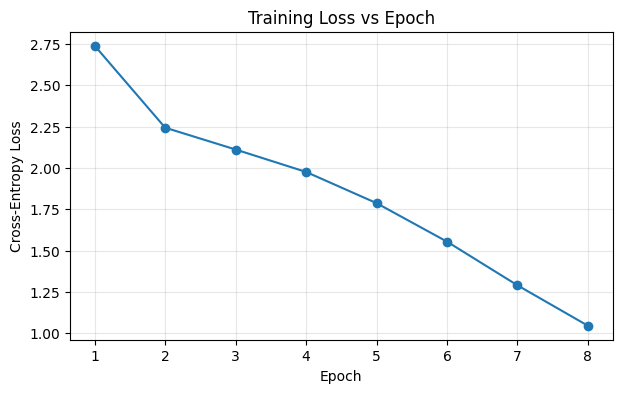

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), losses, marker='o')
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.show()


## Part 4 - Generating text (decoding)

All three ways of decoding use the same basic loop: feed the model whatever text we have so far, look at what it predicts for the very next character, pick one somehow, stick it on the end, and repeat. The only thing that changes between the three methods is how we pick that next character from the logits.


In [13]:
@torch.no_grad()
def generate(prompt, max_new=200, mode="greedy", temperature=1.0, top_k=None):
    # mode can be 'greedy', 'temperature', or 'topk'
    model.eval()
    ids = torch.tensor(encode(prompt), dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new):
        ids_cond = ids[:, -model.seq_len:]  # only keep last seq_len chars, that's all the model can look at
        logits = model(ids_cond)
        last_logits = logits[:, -1, :]  # we only care about the prediction for the next character

        if mode == "greedy":
            next_token = torch.argmax(last_logits, dim=-1, keepdim=True)

        elif mode == "temperature":
            scaled = last_logits / temperature
            probs = F.softmax(scaled, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

        elif mode == "topk":
            scaled = last_logits / temperature
            top_vals, top_idx = torch.topk(scaled, top_k, dim=-1)
            top_probs = F.softmax(top_vals, dim=-1)
            sampled = torch.multinomial(top_probs, num_samples=1)
            next_token = torch.gather(top_idx, -1, sampled)

        else:
            raise ValueError(f"unknown mode: {mode}")

        ids = torch.cat([ids, next_token], dim=1)

    return decode(ids[0].tolist())

prompt = "ROMEO:"


### 4.1 Greedy decoding

Just always takes whatever character the model thinks is most likely. No randomness at all, so running this twice gives the exact same output every time.


In [14]:
print(generate(prompt, max_new=200, mode="greedy"))


ROMEO:
I takee thy word word:
Call me ne be wet;


JULIET:
What that thu thy namat thus Moueld, not, not,
And, nor nor nor nor nor nor bear be ny or or or or be,
Whorme, ny for orme, far fany or or or or or


### 4.2 Temperature sampling

Here I divide the logits by a temperature value before turning them into probabilities. Lower temperature (like 0.5) makes the model more confident/sharp, so it behaves closer to greedy. Higher temperature (like 1.5) flattens things out so less likely characters get picked more often too.

I tried 3 temperatures to actually see the difference: 0.5, 1.0, and 1.5.


In [15]:
set_seed(42)
for T in [0.5, 1.0, 1.5]:
    print(f"=== temperature = {T} ===")
    print(generate(prompt, max_new=200, mode="temperature", temperature=T))
    print()


=== temperature = 0.5 ===


ROMEO:
I take thy name? ame, nor d whar she saind pakll se seas
Rotakers thers aks ays no wother wof would,
Sot me woulldy n ne we wereoulll aswet;
Rot wo theomeo Ro alld,
Rethy wo wo nar nar nor heamer ce


=== temperature = 1.0 ===


ROMEO:
By na name;
Thar ort thain f thar mar fue.
Shal se s as I ak aks:
Dis an to he? al and grtoter nco peres

Berfotheesal at woutin wof.
I athot ams ny mee.
Mor, ldo nor fameor akd, whor worecar rt nor 

=== temperature = 1.5 ===


ROMEO:
W:
DRomeo? Take NoreoULIEO Romeo! wher tho:
:
JULeoULIEs’JULIETw y narell thy anare ean,

zeru fortEO that’s? tuthy sebe wgiLIET:
Arfuu a t nany imort.
Morf nam,ht s I acepa inof, it.
Whot thouNo my 



### 4.3 Top-k sampling

This one only lets the model choose from the top k most likely characters at each step (everything else gets thrown out), then samples from that shortlist. It's kind of a middle ground - keeps some randomness but doesn't let it pick something totally out of nowhere.

I compared a small k (3) against a bigger k (15) so the difference in diversity is actually visible.


In [16]:
set_seed(42)
for k in [3, 15]:
    print(f"=== top-k = {k} (temperature=1.0) ===")
    print(generate(prompt, max_new=200, mode="topk", temperature=1.0, top_k=k))
    print()


=== top-k = 3 (temperature=1.0) ===


ROMEO:
I tall thy ame

I name, nor ar ar tondell be she s


ROMEO:
Beakeak k thysat wo t wo wollo me sanysame the
I wher wo worerd:
Jull Romeo, Ro deo?
Reain whetheowherereor heowhid Rou Romeo?
Deouthy ny f

=== top-k = 15 (temperature=1.0) ===


ROMEO:
Whar at that more, shy not tat nat hor telongh heouser n no name?

Mothe, r nor nd norme par Carthele
JULIETJULIET:
O Romeouthy whyET:
O areoreou at thyself, nameff, t thinathat.
Thor nor mell’n’s al



## Part 5 - Comparing the decoding methods

**Greedy decoding** just grabs the highest probability character every single step. Because of that it's deterministic - same prompt always gives the same output. It tends to be the most "coherent" in the sense that it's always taking the model's best guess, but I noticed it gets stuck in loops pretty easily (you can see it above repeating "or or or or" and "nor nor nor" - once it locks onto a pattern it just keeps going since that pattern keeps looking like the best choice).

**Temperature sampling** changes how sharp or flat the probability distribution is before sampling from it. At T=0.5 the output looks pretty close to greedy - still somewhat repetitive but a little more varied. At T=1.5 it's a lot more random, you start getting weird character combos and broken words that don't really look like English anymore. So temperature is basically a dial between "safe and repetitive" and "random and messy."

**Top-k sampling** cuts off the choices to just the top k candidates so it can't pick something really unlikely. With k=3 it stays pretty close to greedy/low temperature behavior. With k=15 there's a lot more room to pick different characters, so the output is more varied than k=3, but it still avoids the really nonsensical stuff you'd get from unrestricted high temperature sampling since the worst options are never even considered.

**So which one is most coherent?** Greedy decoding, since it's always committing to what the model is most confident about and never taking a risk on a less likely character.

**Which one is most diverse?** High temperature sampling (T=1.5) produces the most different/random output out of everything I tried. If I wanted diversity without it turning into total nonsense, top-k with a larger k (15) seemed like a better tradeoff than raw high temperature.

One big caveat here: `shakespeare.txt` is a really small file (only about 1700 characters), so honestly the model is mostly just memorizing bits of this one passage rather than learning general Shakespearean English. That's why you can see fragments like "ROMEO:", "JULIET:", "name", "Romeo" showing up in basically every output regardless of decoding method. With a much bigger dataset I'd expect this same pattern (greedy = safest/most repetitive, high temperature = most diverse/least coherent, top-k = in between) to still hold, but the actual generated text would look a lot more like real English instead of just echoing back memorized pieces of the training text.

| Method | Coherence | Diversity | Deterministic? |
|---|---|---|---|
| Greedy | highest | lowest | yes |
| Temperature, T=0.5 | high | low-ish | no |
| Temperature, T=1.5 | low | highest | no |
| Top-k, k=3 | high | low-ish | no |
| Top-k, k=15 | medium | high | no |
